In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix


# Loading the dataset
df = pd.read_csv('2021_PUDB_EXPORT_123121.csv').head(20000)

# **Analysis of data before processing**

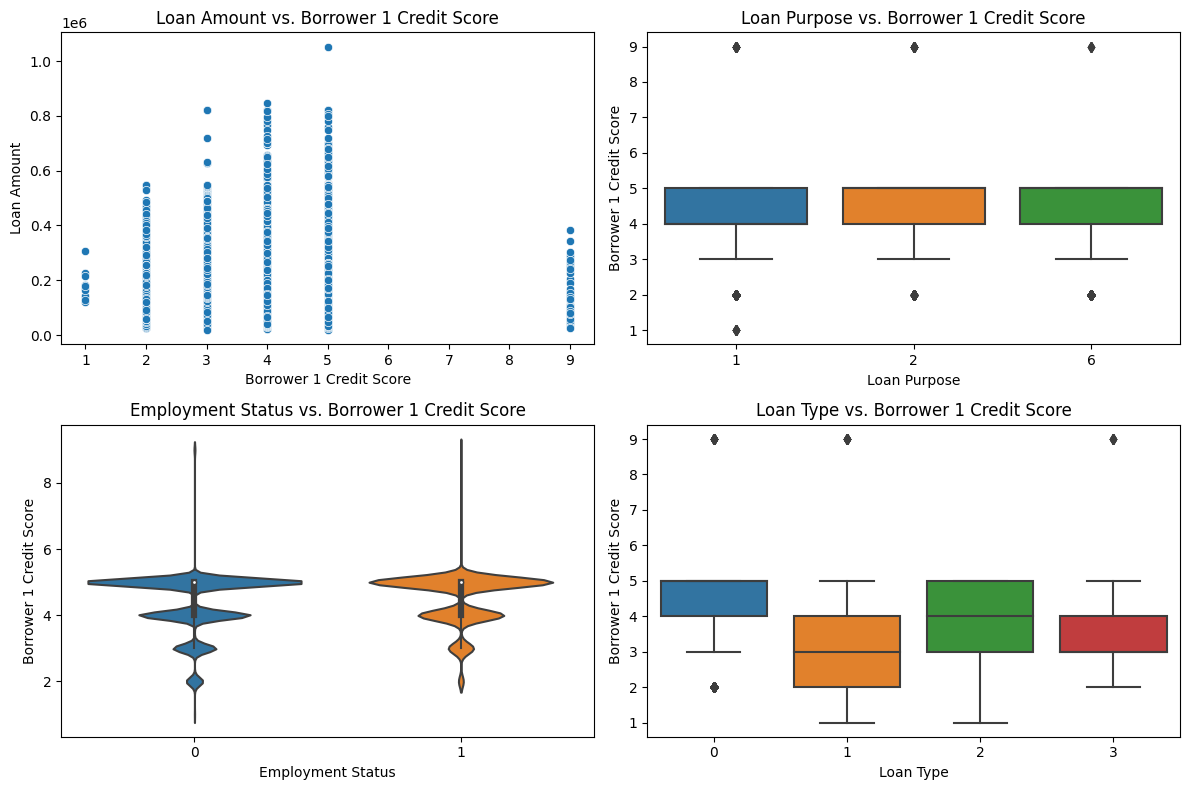

In [2]:
# Set up subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Scatter plot: Loan Amount vs. Borrower 1 Credit Score
sns.scatterplot(x='Borrower1CreditScoreValue', y='NoteAmount', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Loan Amount vs. Borrower 1 Credit Score')
axes[0, 0].set_xlabel('Borrower 1 Credit Score')
axes[0, 0].set_ylabel('Loan Amount')

# Boxplot: Loan Purpose vs. Borrower 1 Credit Score
sns.boxplot(x='LoanPurposeType', y='Borrower1CreditScoreValue', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Loan Purpose vs. Borrower 1 Credit Score')
axes[0, 1].set_xlabel('Loan Purpose')
axes[0, 1].set_ylabel('Borrower 1 Credit Score')

# Violin plot: Employment Status vs. Borrower 1 Credit Score
sns.violinplot(x='EmploymentBorrowerSelfEmployed', y='Borrower1CreditScoreValue', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Employment Status vs. Borrower 1 Credit Score')
axes[1, 0].set_xlabel('Employment Status')
axes[1, 0].set_ylabel('Borrower 1 Credit Score')

# Boxplot: Loan Type vs. Borrower 1 Credit Score
sns.boxplot(x='MortgageType', y='Borrower1CreditScoreValue', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Loan Type vs. Borrower 1 Credit Score')
axes[1, 1].set_xlabel('Loan Type')
axes[1, 1].set_ylabel('Borrower 1 Credit Score')

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

<ipython-input-3-0135befb8830>:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = subset_df.corr()


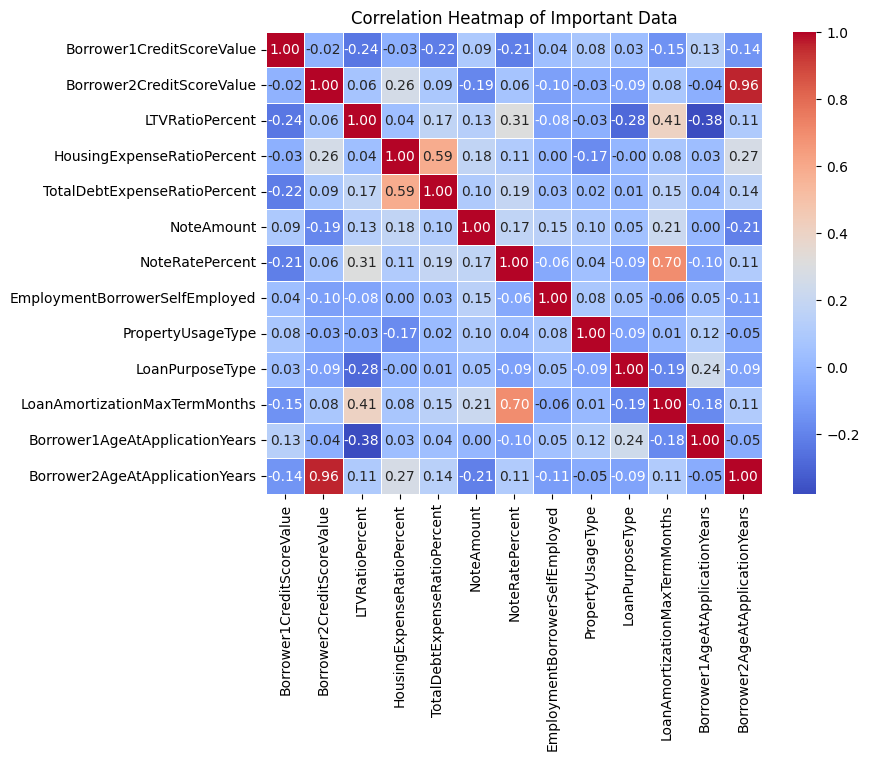

In [3]:
important_data = ['Borrower1CreditScoreValue', 'Borrower2CreditScoreValue', 'LTVRatioPercent', 'HousingExpenseRatioPercent', 'TotalDebtExpenseRatioPercent','NoteAmount', 'NoteRatePercent', 'EmploymentBorrowerSelfEmployed', 'PropertyType', 'PropertyUsageType', 'LoanPurposeType', 'LoanAmortizationMaxTermMonths', 'Borrower1AgeAtApplicationYears', 'Borrower2AgeAtApplicationYears']

# Subset your DataFrame to include only the important data
subset_df = df[important_data]

# Calculate the correlation matrix
correlation_matrix = subset_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Important Data')
plt.show()

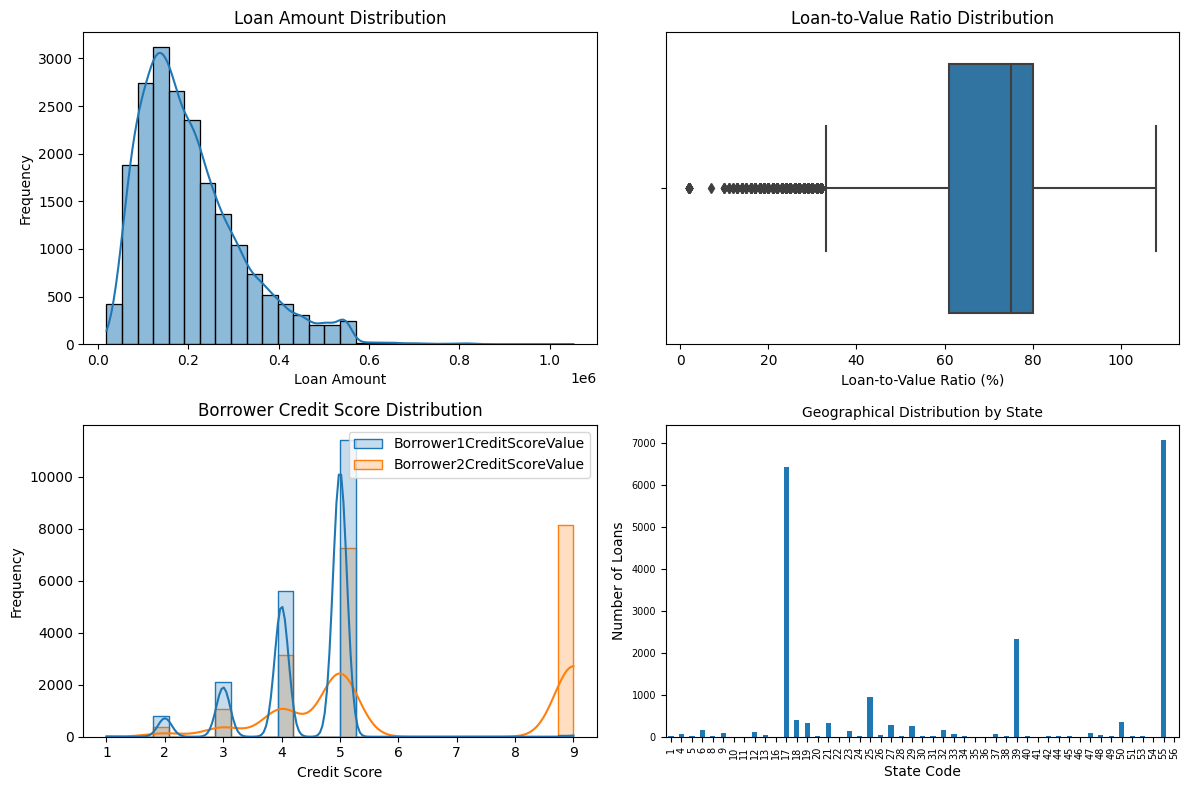

In [4]:
# Set up subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loan Amount Distribution (Histogram)
sns.histplot(df['NoteAmount'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Loan Amount Distribution')
axes[0, 0].set_xlabel('Loan Amount')
axes[0, 0].set_ylabel('Frequency')

# Loan-to-Value Ratio Distribution (Boxplot)
sns.boxplot(x=df['LTVRatioPercent'], ax=axes[0, 1])
axes[0, 1].set_title('Loan-to-Value Ratio Distribution')
axes[0, 1].set_xlabel('Loan-to-Value Ratio (%)')

# Borrower Credit Score Distribution (Histogram)
sns.histplot(df[['Borrower1CreditScoreValue', 'Borrower2CreditScoreValue']], bins=30, kde=True, element="step", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Borrower Credit Score Distribution')
axes[1, 0].set_xlabel('Credit Score')
axes[1, 0].set_ylabel('Frequency')

# Geographical Distribution (Bar Chart)
df['FIPSStateNumericCode'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Geographical Distribution by State', fontsize=10)
axes[1, 1].set_xlabel('State Code')
axes[1, 1].set_ylabel('Number of Loans')
axes[1, 1].tick_params(axis='both', which='major', labelsize=7)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

# **Pre Processing and cleaning**
Upon examining the visualizations presented above, it is evident that certain variables play a more significant role in determining whether a loan is approved. Meanwhile, others seem to have a lesser impact. In the subsequent section, we plan to enhance the data quality by eliminating irrelevant features through a data cleaning process. Additionally, we aim to introduce a new column, "LoanApprovalStatus," tailored to our specific criteria and needs. This step is crucial for streamlining the dataset and focusing on the key factors that influence loan approval decisions.

In [5]:
# Function to generate loan approval status
def generateLoanApprovalStatus(row):
    LP, ITVratio, creditScore, firstHomeBuyer, selfEmployed, typeOfLien = row['LoanPurposeType'], row['LTVRatioPercent'], row['Borrower1CreditScoreValue'], row['BorrowerFirstTimeHomebuyer'], row['EmploymentBorrowerSelfEmployed'], row['LienPriorityType']

    if LP in [1, 4] and ITVratio < 80:
        return "Approved"
    elif firstHomeBuyer == 1 and creditScore >= 620 and selfEmployed == 0 and typeOfLien <=2:
        return "Approved"
    else:
        return "Denied"

# Apply the loan approval status function
df['LoanApprovalStatus'] = df.apply(generateLoanApprovalStatus, axis=1)

# Apply the loan approval status function
df['LoanApprovalStatus'] = df.apply(generateLoanApprovalStatus, axis=1)

# Drop unnecessary columns
columnsToDrop = ['Borrower1Race1Type', 'Borrower2Race1Type', 'Borrower1GenderType', 'Borrower2GenderType', 'Borrower1AgeAtApplicationYears', 'Borrower2AgeAtApplicationYears', 'Borrower1EthnicityType', 'Borrower1Race2Type', 'Borrower1Race3Type', 'Borrower1Race4Type', 'Borrower1Race5Type', 'Borrower2EthnicityType', 'Borrower2Race2Type', 'Borrower2Race3Type', 'Borrower2Race4Type', 'Borrower2Race5Type']
df = df.drop(columns=columnsToDrop, axis=1)

# One-hot encode categorical columns
dfEncoded = pd.get_dummies(df, columns=["PropertyType", "LoanPurposeType", "LienPriorityType"], drop_first=True)

# Drop additional columns
columnsToDrop = ['Year', 'LoanCharacteristicsID', 'Bank', 'FIPSStateNumericCode', 'FIPSCountyCode','CoreBasedStatisticalAreaCode', 'PrepaymentPenaltyExpirationDate']
dfEncoded = dfEncoded.drop(columns=columnsToDrop, axis=1)

# **Train and test plain classification models**
#Separate Features and Targets:

Features are extracted by removing the 'LoanApprovalStatus' column from the encoded DataFrame.
The target variable is isolated by selecting only the 'LoanApprovalStatus' column.
#Encode Target Variable:

The target variable is transformed using a LabelEncoder to convert categorical labels into numerical values.
#Split the Dataset:

The dataset is divided into training and testing sets using the train_test_split function.
#Standardize the Data:

Features are standardized to have a mean of 0 and a standard deviation of 1 using StandardScaler.
#Define a Function for Model Evaluation:

A function is created to train a model, make predictions, and evaluate its performance using metrics such as accuracy, precision, F1 score, recall, and confusion matrix.
#Classification Models:

Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM) models are instantiated and evaluated using the defined evaluation function.
# Compare Model Performance:

A DataFrame is generated to compare the performance metrics of different classification models, including accuracy, precision, F1 score, recall, and confusion matrix.

In [6]:
# Separate features and targets
featuresCls = dfEncoded.drop(['LoanApprovalStatus'], axis=1)
targetsCls = dfEncoded[['LoanApprovalStatus']]

# Encode target variable
le = LabelEncoder()
targetsCls['LoanApprovalStatus'] = le.fit_transform(targetsCls['LoanApprovalStatus'])

# Split the dataset into training and testing sets
featuresClsTrain, featuresClsTest, targetsClsTrain, targetsClsTest = train_test_split(featuresCls, targetsCls, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
featuresClsTrainScaled = scaler.fit_transform(featuresClsTrain)
featuresClsTestScaled = scaler.transform(featuresClsTest)

# Define a function for model evaluation
def evaluateModel(model, features, targets):
    model.fit(features, targets)
    targetsPred = model.predict(featuresClsTestScaled)
    return {
        'Accuracy': accuracy_score(targetsClsTest, targetsPred),
        'Precision': precision_score(targetsClsTest, targetsPred),
        'F1 Score': f1_score(targetsClsTest, targetsPred),
        'Recall': recall_score(targetsClsTest, targetsPred),
        'Confusion Matrix': confusion_matrix(targetsClsTest, targetsPred)
    }

# Logistic Regression (Binary Classification)
logReg = LogisticRegression()
logRegResults = evaluateModel(logReg, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

# Decision Tree Classification
dt = DecisionTreeClassifier()
dtResults = evaluateModel(dt, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

# Random Forest Classification
rfCls = RandomForestClassifier()
rfResults = evaluateModel(rfCls, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

# SVM Classification
svmCls = SVC()
svmResults = evaluateModel(svmCls, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

# Compare the performance of the classification models
lasModels = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
lasResults = pd.DataFrame({
    'Model': lasModels,
    'Accuracy': [logRegResults['Accuracy'], dtResults['Accuracy'], rfResults['Accuracy'], svmResults['Accuracy']],
    'Precision': [logRegResults['Precision'], dtResults['Precision'], rfResults['Precision'], svmResults['Precision']],
    'F1 Score': [logRegResults['F1 Score'], dtResults['F1 Score'], rfResults['F1 Score'], svmResults['F1 Score']],
    'Recall': [logRegResults['Recall'], dtResults['Recall'], rfResults['Recall'], svmResults['Recall']],
    'Confusion Matrix': [logRegResults['Confusion Matrix'], dtResults['Confusion Matrix'], rfResults['Confusion Matrix'], svmResults['Confusion Matrix']]
})


<ipython-input-6-0233cd145431>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  targetsCls['LoanApprovalStatus'] = le.fit_transform(targetsCls['LoanApprovalStatus'])


# **Results**

In [7]:
lasResults.head()

,Model,Accuracy,Precision,F1 Score,Recall,Confusion Matrix
0,Logistic Regression,0.9875,0.986990,0.993453,1.0,"[[235, 75], [0, 5690]]"
1,Decision Tree,1.0000,1.000000,1.000000,1.0,"[[310, 0], [0, 5690]]"
2,Random Forest,1.0000,1.000000,1.000000,1.0,"[[310, 0], [0, 5690]]"
3,SVM,0.9750,0.974315,0.986990,1.0,"[[160, 150], [0, 5690]]"


# **Hyper Parameter Tuning**

In the given dataset, it has been observed that both the Decision Tree and Random Forest models exhibit a tendency towards overfitting on multiple occasions. In light of this, a deliberate approach has been taken to refine the model selection process. Specifically, hyperparameter tuning has been conducted on the remaining two models. This meticulous optimization aims to identify the most suitable model for the dataset, considering factors such as generalization performance and avoidance of overfitting tendencies.

In [8]:
# Hyperparameter tuning for Logistic Regression
paramGridLogReg = {
    'C': [ 0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

logReg = LogisticRegression()

logRegCV = GridSearchCV(logReg, paramGridLogReg, cv=5, n_jobs=4)
logRegCV.fit(featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

bestParamsLogReg = logRegCV.best_params_
print("Best Hyperparameters for Logistic Regression:", bestParamsLogReg)

Best Hyperparameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [9]:
# Hyperparameter tuning for Support Vector Machine (SVM)
paramGridSVM = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svmCls = SVC()

svmCV = GridSearchCV(svmCls, paramGridSVM, cv=5)
svmCV.fit(featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

bestParamsSVM = svmCV.best_params_
print("Best Hyperparameters for SVM:", bestParamsSVM)

Best Hyperparameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


# **Run Classifications with the obtained hyperparameters**

In [10]:
# Logistic Regression
logRegTuned = LogisticRegression(C=bestParamsLogReg['C'], penalty=bestParamsLogReg['penalty'], solver=bestParamsLogReg['solver'])
logRegResults = evaluateModel(logRegTuned, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

#SVM
svmTuned = SVC(C=bestParamsSVM['C'], kernel=bestParamsSVM['kernel'], gamma=bestParamsSVM['gamma'])
svmResults = evaluateModel(svmTuned, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])

lasModelsTuned = ['Logistic Regression', 'SVM']
lasResultsTuned = pd.DataFrame({
    'Model': lasModelsTuned,
    'Accuracy': [logRegResults['Accuracy'], svmResults['Accuracy']],
    'Precision': [logRegResults['Precision'], svmResults['Precision']],
    'F1 Score': [logRegResults['F1 Score'], svmResults['F1 Score']],
    'Recall': [logRegResults['Recall'], svmResults['Recall']],
    'Confusion Matrix': [logRegResults['Confusion Matrix'], svmResults['Confusion Matrix']]
})

# **Resuts After Tuning**

In [11]:
lasResultsTuned.head()

,Model,Accuracy,Precision,F1 Score,Recall,Confusion Matrix
0,Logistic Regression,0.995000,0.994755,0.997371,1.0,"[[280, 30], [0, 5690]]"
1,SVM,0.996833,0.996672,0.998333,1.0,"[[291, 19], [0, 5690]]"


Both models exhibit extremely high accuracy, precision, and recall, with the F1 Score providing a balanced measure of precision and recall. The absence of false negatives in both cases indicates that the models are successfully identifying all positive instances. These results suggest that both Logistic Regression and SVM, with the specified hyperparameters, are well-suited for the classification task at hand.

# **Regression Models**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import math

featuresReg = dfEncoded.drop(['NoteRatePercent','LoanApprovalStatus'], axis=1)
targetsReg = dfEncoded[['NoteRatePercent']]

targetsReg = le.fit_transform(targetsReg)

# Splitting the dataset into training and testing sets
featuresTrain, featuresTest, targetsTrain, targetsTest = train_test_split(featuresReg, targetsReg, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
featuresTrainScaled, featuresTestScaled = scaler.fit_transform(featuresTrain), scaler.transform(featuresTest)

# Model training and prediction
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'SVM Regressor': SVR()
}

def evaluateModelReg(model):
    model.fit(featuresTrainScaled, targetsTrain)
    targetsPred = model.predict(featuresTestScaled)
    return {
        'R2': r2_score(targetsTest, targetsPred),
        'MSE': mean_squared_error(targetsTest, targetsPred),
        'RMSE': math.sqrt(mean_squared_error(targetsTest, targetsPred))
    }

results = {}

for name, model in models.items():
    results[name] = evaluateModelReg(model)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
pd.DataFrame(results)

,Linear Regression,Decision Tree Regressor,Random Forest Regressor,SVM Regressor
R2,0.526447,0.281719,0.643826,0.535442
MSE,49.618128,75.260250,37.319345,48.675571
RMSE,7.044014,8.675267,6.108956,6.976788


Based on these metrics, it appears that the Random Forest Regressor has the best performance, as it has the highest R2 value (indicating better fit), the lowest MSE, and a relatively low RMSE. Therefore, the Random Forest Regressor might be considered the best model among the ones you've evaluated.

# **Applying the Trained models on Merged datasets**

In [40]:
df1 = pd.read_csv('2020_PUDB_EXPORT_123120.csv').head(10000)
df2 = pd.read_csv('2020_PUDB_EXPORT_123120.csv').head(10000)

# Function to generate loan approval status
def generateLoanApprovalStatus(row):
    LP, ITVratio, creditScore, firstHomeBuyer, selfEmployed, typeOfLien = row['LoanPurposeType'], row['LTVRatioPercent'], row['Borrower1CreditScoreValue'], row['BorrowerFirstTimeHomebuyer'], row['EmploymentBorrowerSelfEmployed'], row['LienPriorityType']

    if LP in [1, 4] and ITVratio < 80:
        return "Approved"
    elif firstHomeBuyer == 1 and creditScore >= 620 and selfEmployed == 0 and typeOfLien <=2:
        return "Approved"
    else:
        return "Denied"

# Apply the loan approval status function
df1['LoanApprovalStatus'] = df1.apply(generateLoanApprovalStatus, axis=1)

# Apply the loan approval status function
df1['LoanApprovalStatus'] = df1.apply(generateLoanApprovalStatus, axis=1)

# Drop unnecessary columns
columnsToDrop = ['Borrower1Race1Type', 'Borrower2Race1Type', 'Borrower1GenderType', 'Borrower2GenderType', 'Borrower1AgeAtApplicationYears', 'Borrower2AgeAtApplicationYears', 'Borrower1EthnicityType', 'Borrower1Race2Type', 'Borrower1Race3Type', 'Borrower1Race4Type', 'Borrower1Race5Type', 'Borrower2EthnicityType', 'Borrower2Race2Type', 'Borrower2Race3Type', 'Borrower2Race4Type', 'Borrower2Race5Type']
df1 = df1.drop(columns=columnsToDrop, axis=1)

# One-hot encode categorical columns
df1Encoded = pd.get_dummies(df1, columns=["PropertyType", "LoanPurposeType", "LienPriorityType"], drop_first=True)

# Drop additional columns
columnsToDrop = ['Year', 'LoanCharacteristicsID', 'Bank', 'FIPSStateNumericCode', 'FIPSCountyCode','CoreBasedStatisticalAreaCode', 'PrepaymentPenaltyExpirationDate']
df1Encoded = df1Encoded.drop(columns=columnsToDrop, axis=1)

# Function to generate loan approval status
def generateLoanApprovalStatus(row):
    LP, ITVratio, creditScore, firstHomeBuyer, selfEmployed, typeOfLien = row['LoanPurposeType'], row['LTVRatioPercent'], row['Borrower1CreditScoreValue'], row['BorrowerFirstTimeHomebuyer'], row['EmploymentBorrowerSelfEmployed'], row['LienPriorityType']

    if LP in [1, 4] and ITVratio < 80:
        return "Approved"
    elif firstHomeBuyer == 1 and creditScore >= 620 and selfEmployed == 0 and typeOfLien <=2:
        return "Approved"
    else:
        return "Denied"

# Apply the loan approval status function
df2['LoanApprovalStatus'] = df2.apply(generateLoanApprovalStatus, axis=1)

# Apply the loan approval status function
df2['LoanApprovalStatus'] = df2.apply(generateLoanApprovalStatus, axis=1)

# Drop unnecessary columns
columnsToDrop = ['Borrower1Race1Type', 'Borrower2Race1Type', 'Borrower1GenderType', 'Borrower2GenderType', 'Borrower1AgeAtApplicationYears', 'Borrower2AgeAtApplicationYears', 'Borrower1EthnicityType', 'Borrower1Race2Type', 'Borrower1Race3Type', 'Borrower1Race4Type', 'Borrower1Race5Type', 'Borrower2EthnicityType', 'Borrower2Race2Type', 'Borrower2Race3Type', 'Borrower2Race4Type', 'Borrower2Race5Type']
df2 = df2.drop(columns=columnsToDrop, axis=1)

# One-hot encode categorical columns
df2Encoded = pd.get_dummies(df2, columns=["PropertyType", "LoanPurposeType", "LienPriorityType"], drop_first=True)

# Drop additional columns
columnsToDrop = ['Year', 'LoanCharacteristicsID', 'Bank', 'FIPSStateNumericCode', 'FIPSCountyCode','CoreBasedStatisticalAreaCode', 'PrepaymentPenaltyExpirationDate']
df2Encoded = df2Encoded.drop(columns=columnsToDrop, axis=1)

dfEncoded = pd.concat([df1Encoded, df2Encoded])

In [37]:
# Separate features and targets
featuresCls = dfEncoded.drop(['LoanApprovalStatus'], axis=1)
targetsCls = dfEncoded[['LoanApprovalStatus']]

# Encode target variable
le = LabelEncoder()
targetsCls['LoanApprovalStatus'] = le.fit_transform(targetsCls['LoanApprovalStatus'])

# Split the dataset into training and testing sets
featuresClsTrain, featuresClsTest, targetsClsTrain, targetsClsTest = train_test_split(featuresCls, targetsCls, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
featuresClsTrainScaled = scaler.fit_transform(featuresClsTrain)
featuresClsTestScaled = scaler.transform(featuresClsTest)

featuresReg = dfEncoded.drop(['NoteRatePercent','LoanApprovalStatus'], axis=1)
targetsReg = dfEncoded[['NoteRatePercent']]

targetsReg = le.fit_transform(targetsReg)

# Splitting the dataset into training and testing sets
featuresTrain, featuresTest, targetsTrain, targetsTest = train_test_split(featuresReg, targetsReg, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
featuresTrainScaled, featuresTestScaled = scaler.fit_transform(featuresTrain), scaler.transform(featuresTest)

svmResults = evaluateModel(svmTuned, featuresClsTrainScaled, targetsClsTrain['LoanApprovalStatus'])
randomForestRegressorResults = evaluateModelReg(RandomForestRegressor())

<ipython-input-37-35a7b5a847fd>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  targetsCls['LoanApprovalStatus'] = le.fit_transform(targetsCls['LoanApprovalStatus'])
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [38]:
pd.DataFrame({'SVM' : svmResults})

,SVM
Accuracy,0.998167
Confusion Matrix,"[[261, 11], [0, 5728]]"
F1 Score,0.999041
Precision,0.998083
Recall,1.0


In [39]:
pd.DataFrame({'Random Forest' : randomForestRegressorResults})

,Random Forest
MSE,17.781665
R2,0.878259
RMSE,4.216831


The second dataset strengthens the promising results observed in the initial findings, demonstrating the models' effectiveness across diverse scenarios. These consistent positive outcomes underscore the adaptability and reliability of the trained models, confirming their potential for real-world applications. The broader range of input variables in the second dataset further validates the models' versatility, enhancing confidence in their overall performance and applicability.